<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

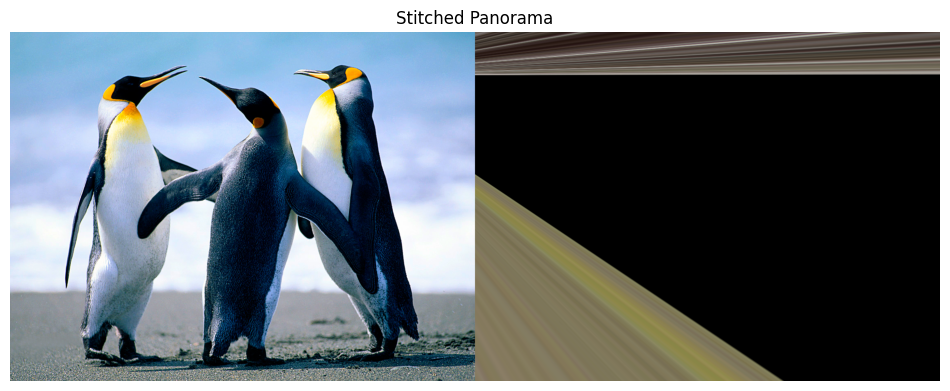

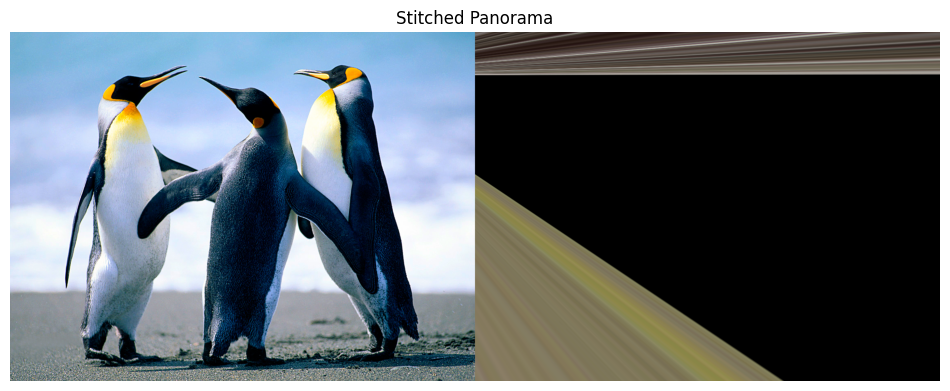

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- UPDATED FILE NAMES ---
img_left = cv2.imread("test1.jpg")
img_right = cv2.imread("test2.jpg")

if img_left is None or img_right is None:
    raise FileNotFoundError("Check that 'test1.jpg' and 'test2.jpg' are in the sidebar.")

# Convert to grayscale for feature matching
gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

# Initialize ORB
orb = cv2.ORB_create(nfeatures=2000)
kp1, des1 = orb.detectAndCompute(gray_left, None)
kp2, des2 = orb.detectAndCompute(gray_right, None)

# Match features
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)
good_matches = matches[:150]

# Compute Homography
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Create Panorama
h1, w1 = img_left.shape[:2]
h2, w2 = img_right.shape[:2]

# Warp left image onto the coordinate system
panorama = cv2.warpPerspective(img_left, H, (w1 + w2, h2))

# Stitch: Overlay the right image onto the panorama
panorama[0:h2, 0:w2] = img_right

# Show results
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title("Stitched Panorama")
plt.axis("off")
plt.show()